# Prac 06.1

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

In [15]:
import cv2
import dlib
import matplotlib.pyplot as plt
import random

In [16]:
# Replace 'path_to_your_image.jpg' with your actual file name
img = cv2.imread('../data/zelensky.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [17]:
detector = dlib.get_frontal_face_detector()

In [18]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = detector(gray)

print(f"Number of faces detected: {len(faces)}")

Number of faces detected: 1


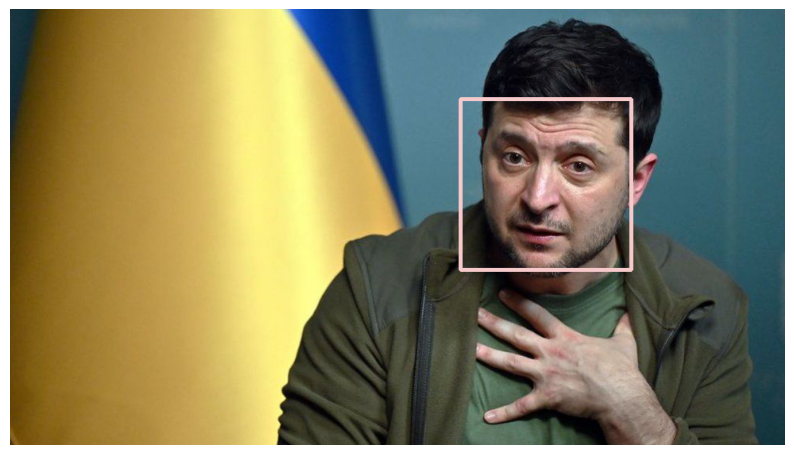

In [19]:
for face in faces:
    # Get coordinates
    x1, y1 = face.left(), face.top()
    x2, y2 = face.right(), face.bottom()
    
    # Generate a random color (R, G, B)
    color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    
    # Draw the rectangle (note: cv2 uses BGR for colors, 
    # but since we are plotting the RGB image, we treat it as RGB)
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 3)

# Plot the final image
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [20]:
import time

Experimenting with: eu_summit.jpg


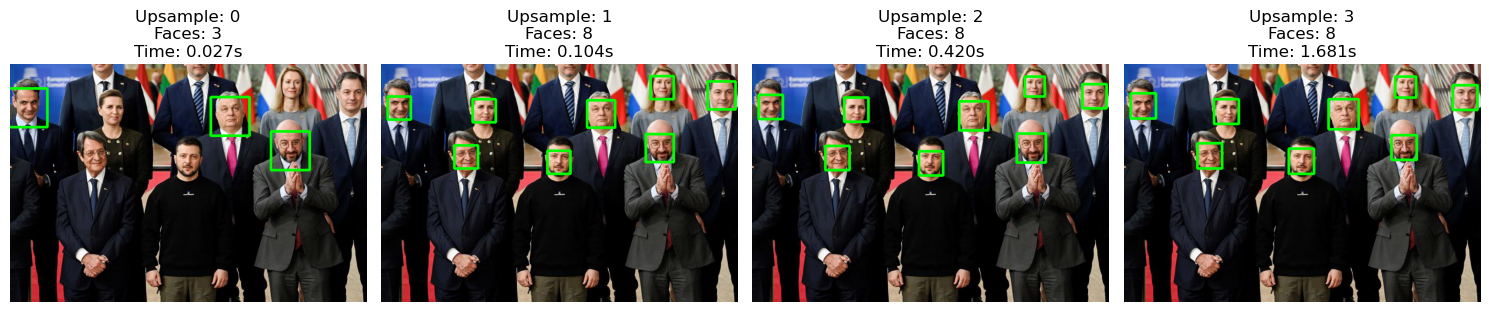

Experimenting with: summit-smiles-ski.jpg


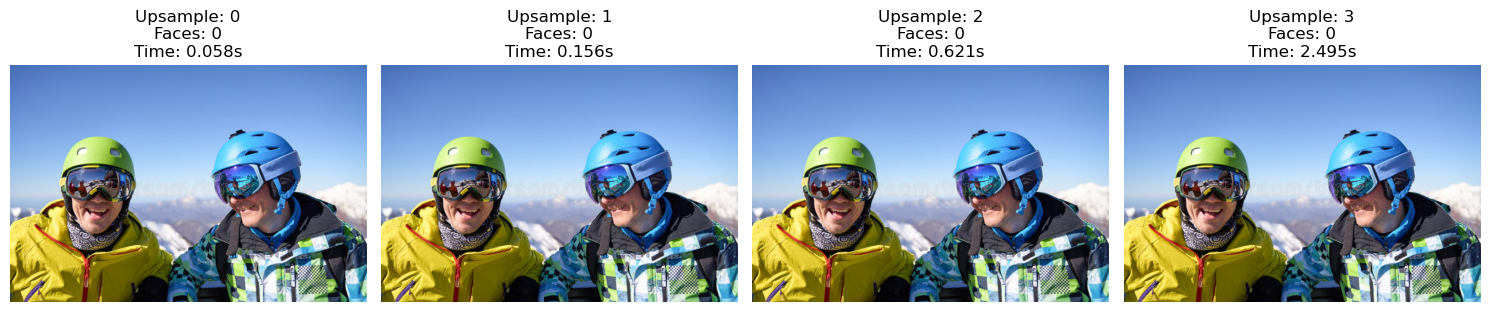

Experimenting with: sunglasses.png


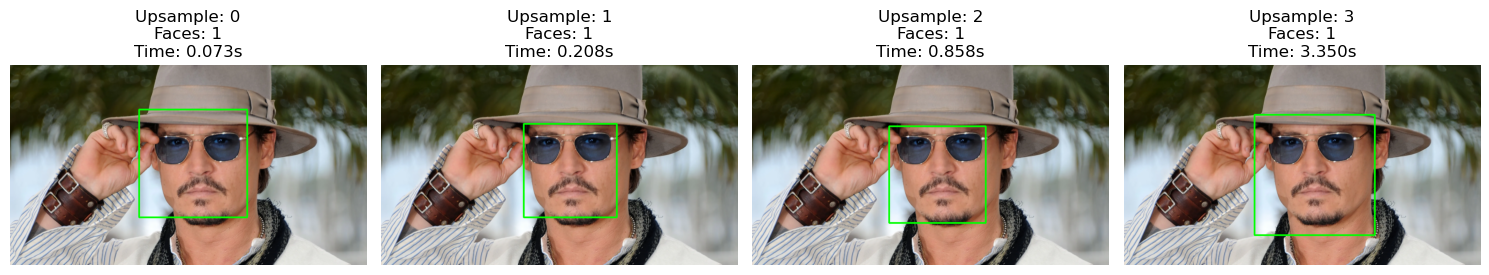

In [21]:
detector = dlib.get_frontal_face_detector()

def experiment_detection(image_path, upsample_levels=[0, 1]):
    """
    Runs an experiment on a specific image with different upsampling levels
    to test robustness.
    """

    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not find {image_path}")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    fig, axes = plt.subplots(1, len(upsample_levels), figsize=(15, 7))

    if len(upsample_levels) == 1: axes = [axes]

    for i, level in enumerate(upsample_levels):
        start_time = time.time()
        
        faces = detector(gray, level)
        
        end_time = time.time()
        process_time = end_time - start_time
        
        output_img = img_rgb.copy()
        for face in faces:
            cv2.rectangle(output_img, (face.left(), face.top()), 
                          (face.right(), face.bottom()), (0, 255, 0), 4)
        
        axes[i].imshow(output_img)
        axes[i].set_title(f"Upsample: {level}\nFaces: {len(faces)}\nTime: {process_time:.3f}s")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

challenging_images = ['eu_summit.jpg', 'summit-smiles-ski.jpg', 'sunglasses.png']

for img_path in challenging_images:
    print(f"Experimenting with: {img_path}")
    experiment_detection('../data/' + img_path, upsample_levels=[0, 1, 2, 3])